In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

sns.set_style("darkgrid")
sns.set_theme(
    "notebook",
    rc={
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    },
)
palette = ["gray", "darkgoldenrod"]
sns.set_palette(["darkgoldenrod", "gray"])

In [2]:
df = pd.read_csv("data/all-data.csv")

In [3]:
df.shape

(150000, 38)

In [4]:
df.head()

,tx_id,timestamp,user_id,merchant_id,amount_uzs,channel,hour_of_day,day_of_week,is_weekend,session_duration_sec,...,region_merchant,mcc_code,risk_score,avg_transaction_uzs,is_online,years_registered,account_age,is_cross_region_tx,amount_vs_merchant_avg,amount_income_ratio
0,T00000000,2023-01-01 00:02:02,U000611,M01182,92883,qr,0,6,1,502,...,Surxondaryo,5107,44.3,141766,0,9,112,1,0.655181,0.034913
1,T00000001,2023-01-01 00:08:28,U001904,M01090,35578,web,0,6,1,325,...,Sirdaryo,6245,27.4,157290,1,2,811,1,0.226192,0.020330
2,T00000002,2023-01-01 00:15:25,U010006,M02389,229695,web,0,6,1,17,...,Samarkand,8623,42.3,394316,0,5,1448,1,0.582514,0.083551
3,T00000003,2023-01-01 00:16:27,U010291,M00743,134764,app,0,6,1,24,...,Andijan,5476,25.2,240870,1,1,1239,1,0.559486,0.058150
4,T00000004,2023-01-01 00:20:50,U003685,M01892,650334,qr,0,6,1,133,...,Sirdaryo,9500,44.5,81823,0,3,-322,1,7.947961,0.368658


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   tx_id                   150000 non-null  str    
 1   timestamp               150000 non-null  str    
 2   user_id                 150000 non-null  str    
 3   merchant_id             150000 non-null  str    
 4   amount_uzs              150000 non-null  int64  
 5   channel                 150000 non-null  str    
 6   hour_of_day             150000 non-null  int64  
 7   day_of_week             150000 non-null  int64  
 8   is_weekend              150000 non-null  int64  
 9   session_duration_sec    150000 non-null  int64  
 10  login_attempts          150000 non-null  int64  
 11  is_cross_city_tx        150000 non-null  int64  
 12  is_fraud                150000 non-null  int64  
 13  name                    150000 non-null  str    
 14  gender                  150000 

## Exploratory Data Analysis

Note that this excludes identifiers: unique IDs and name data from analysis.

In [6]:
exclude_ids = [
    "tx_id",
    "name",
    "user_id",
    "merchant_id",
    "merchant_name",
    "timestamp",
    "registration_date",
]

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_ids + ["is_fraud"]]

cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols = [c for c in cat_cols if c not in exclude_ids]

print(f"Numerical ({len(num_cols)}):")
for col in num_cols:
    print(f"- {col}")

print(f"\nCategorical ({len(cat_cols)}):")
for col in cat_cols:
    print(f"- {col}")

Numerical (21):
- amount_uzs
- hour_of_day
- day_of_week
- is_weekend
- session_duration_sec
- login_attempts
- is_cross_city_tx
- age
- credit_score
- monthly_income_uzs
- identity_verified
- historical_tx_count
- mcc_code
- risk_score
- avg_transaction_uzs
- is_online
- years_registered
- account_age
- is_cross_region_tx
- amount_vs_merchant_avg
- amount_income_ratio

Categorical (9):
- channel
- gender
- city_user
- region_user
- primary_app
- preferred_device
- category
- city_merchant
- region_merchant


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_uzs,150000.0,2.734819e+05,4.116896e+05,1048.000000,7.123725e+04,1.490800e+05,3.153272e+05,1.790924e+07
hour_of_day,150000.0,1.151967e+01,6.916038e+00,0.000000,6.000000e+00,1.200000e+01,1.800000e+01,2.300000e+01
day_of_week,150000.0,2.993793e+00,2.005421e+00,0.000000,1.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00
is_weekend,150000.0,2.860933e-01,4.519351e-01,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
session_duration_sec,150000.0,4.530738e+02,2.587620e+02,5.000000,2.290000e+02,4.530000e+02,6.780000e+02,8.990000e+02
login_attempts,150000.0,2.265500e+00,1.477068e+00,1.000000,1.000000e+00,2.000000e+00,4.000000e+00,5.000000e+00
is_cross_city_tx,150000.0,9.150600e-01,2.787933e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
is_fraud,150000.0,3.470000e-02,1.830195e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
age,150000.0,4.432458e+01,1.551220e+01,18.000000,3.100000e+01,4.400000e+01,5.800000e+01,7.100000e+01
credit_score,150000.0,5.508402e+02,1.180213e+02,300.000000,4.690000e+02,5.500000e+02,6.320000e+02,8.500000e+02


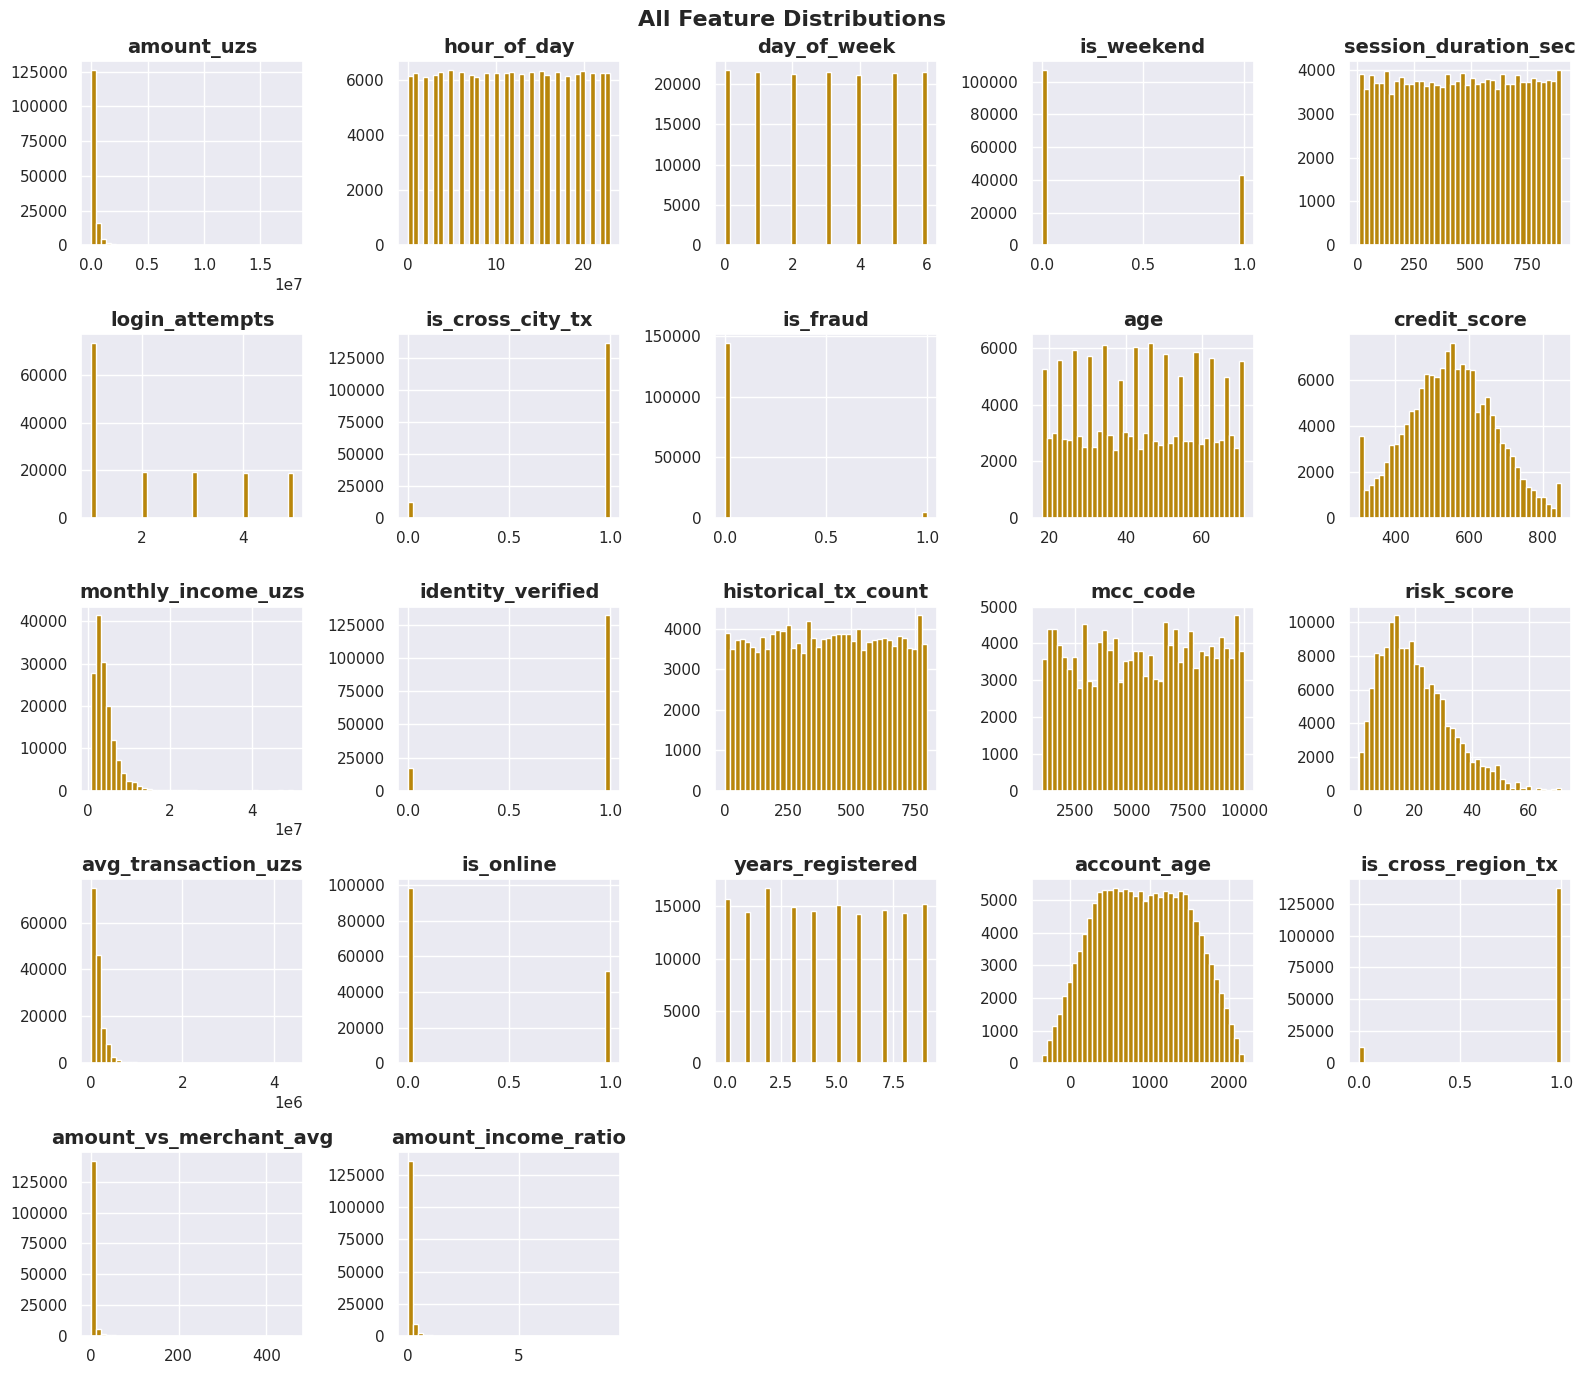

In [8]:
df.hist(figsize=(16, 14), bins=40)
plt.suptitle("All Feature Distributions")
plt.tight_layout()
plt.show()

Notable analysis:

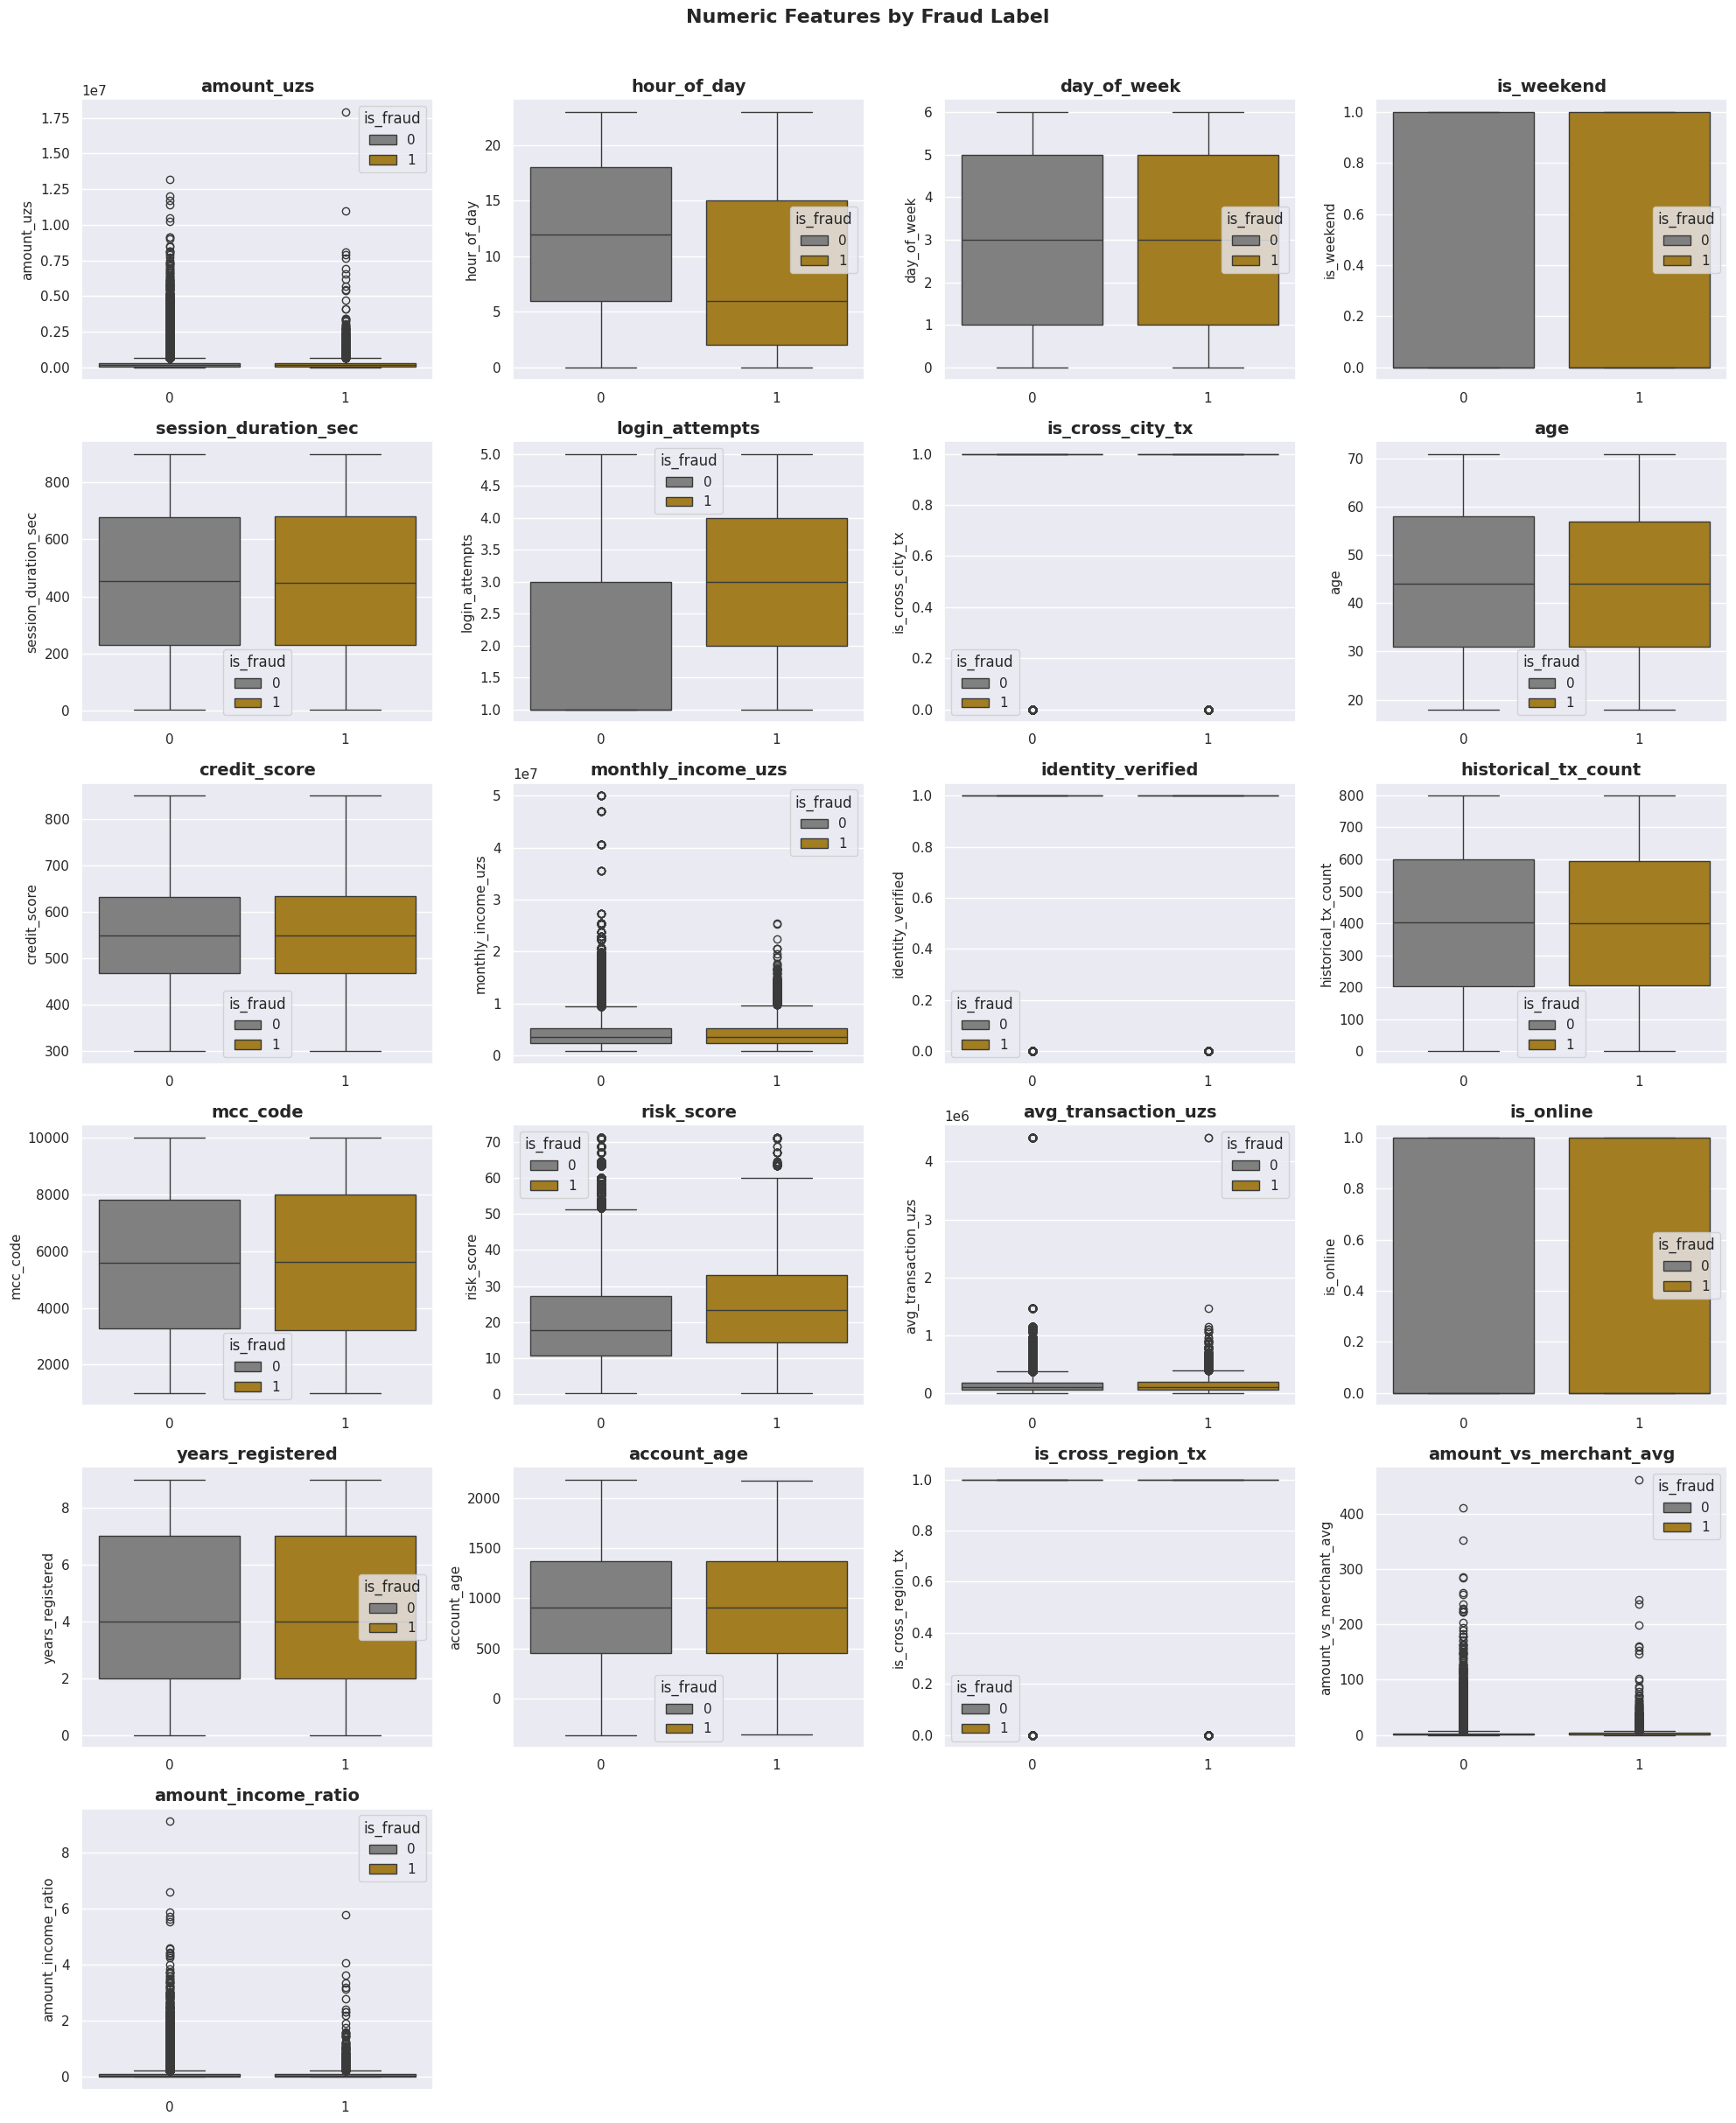

In [9]:
ncols = 4
nrows = math.ceil(len(num_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        data=df,
        x="is_fraud",
        y=col,
        ax=ax,
        hue="is_fraud",
        palette=["gray", "darkgoldenrod"],
    )
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(num_cols) :]:
    ax.set_visible(False)

plt.suptitle("Numeric Features by Fraud Label", y=1.01)
plt.tight_layout()
plt.show()

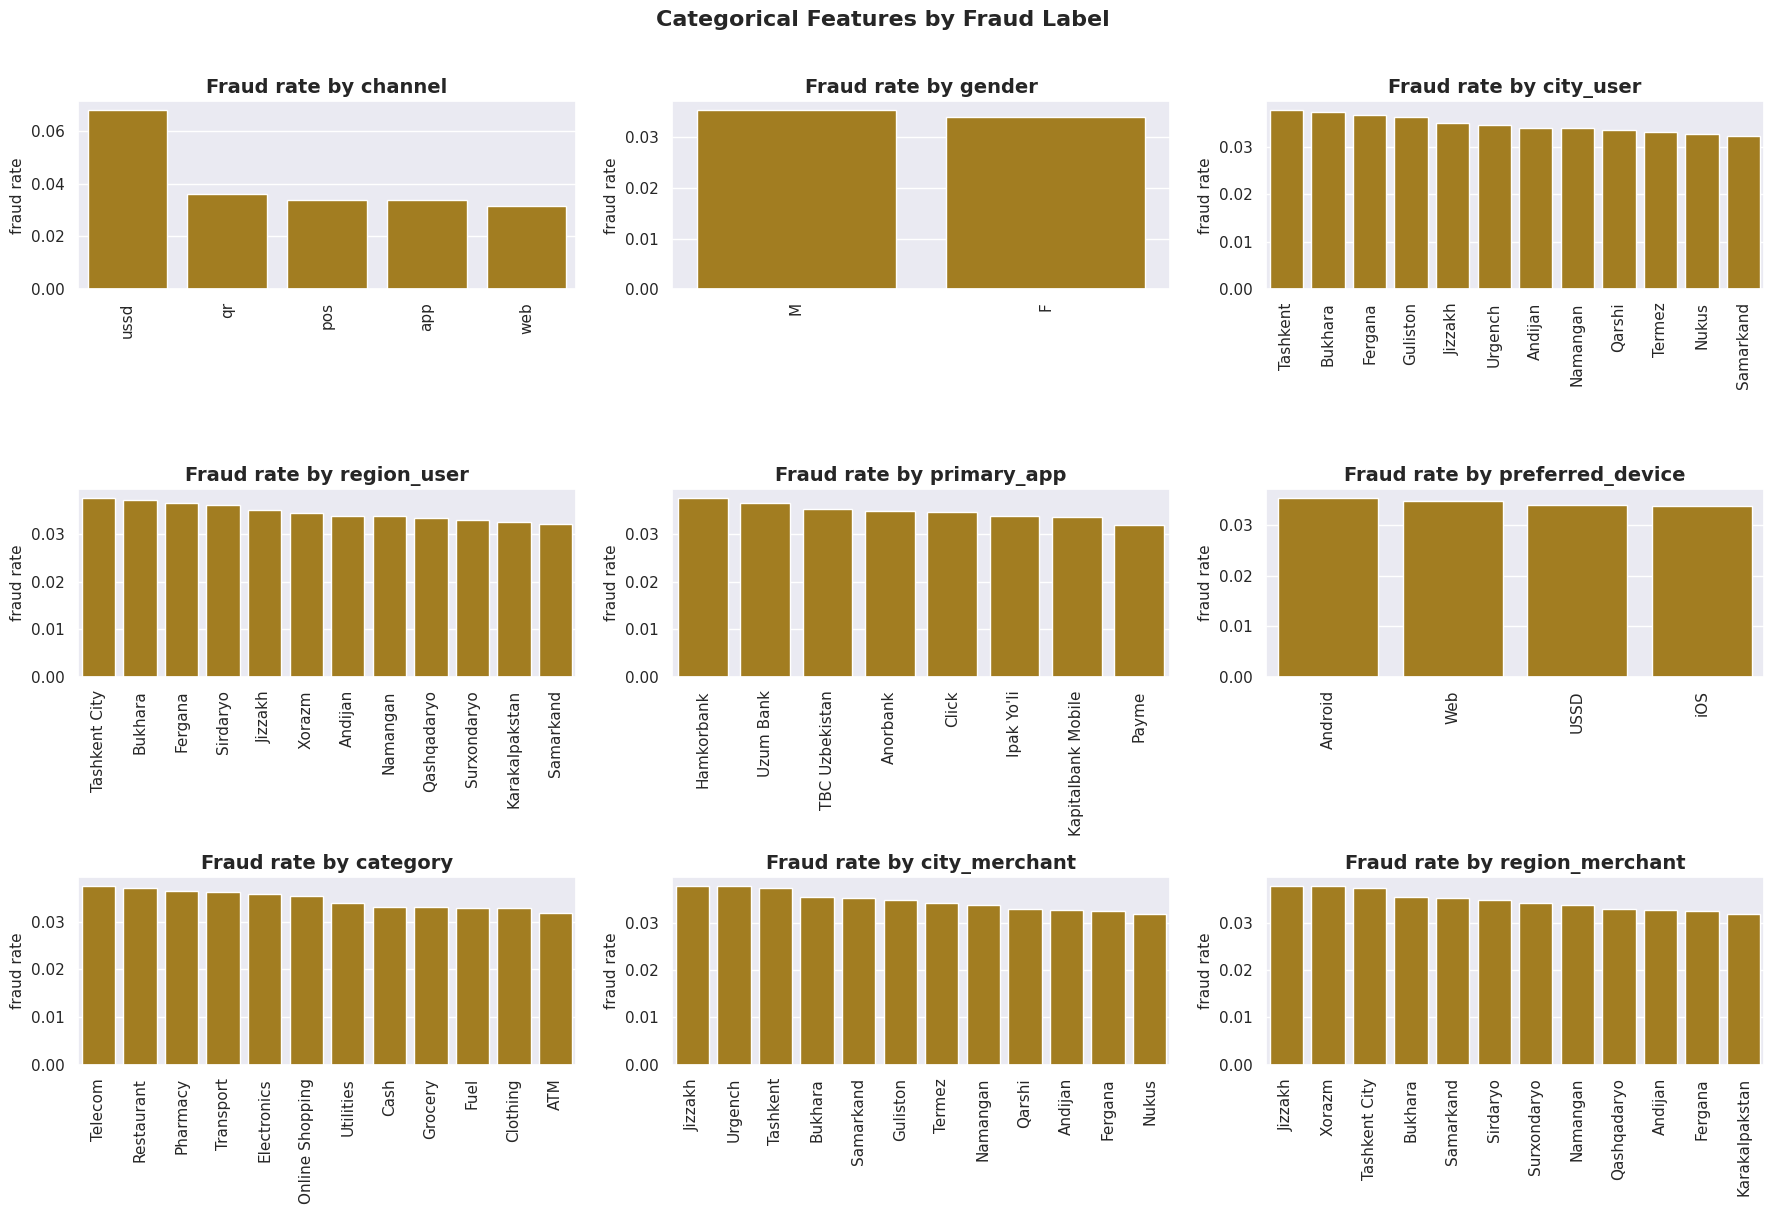

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    fraud_rate = df.groupby(col)["is_fraud"].mean().sort_values(ascending=False)
    sns.barplot(x=fraud_rate.index, y=fraud_rate.values, ax=ax)
    ax.set_title(f"Fraud rate by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("fraud rate")
    ax.tick_params(axis="x", rotation=90)

plt.suptitle("Categorical Features by Fraud Label", y=1.01)
plt.tight_layout()
plt.show()

### Correlations

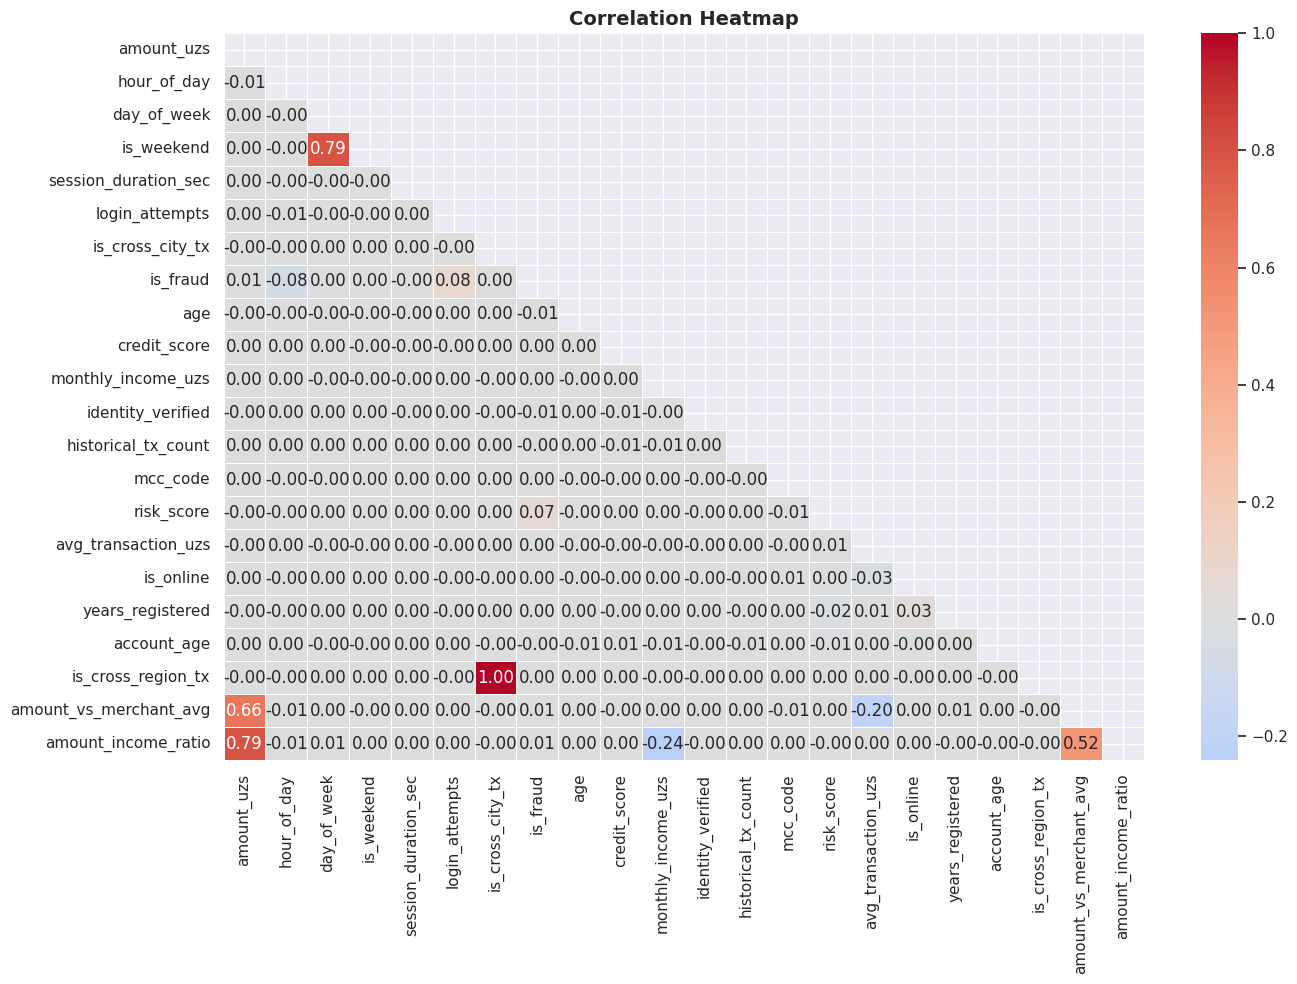

In [11]:
corr = df.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

We will keep both cross-region and cross-city checks even if signal strength is similar, it can flag different fraud patterns to cover both local anomalies & broader geographic anomalies

Correlations with Fraud

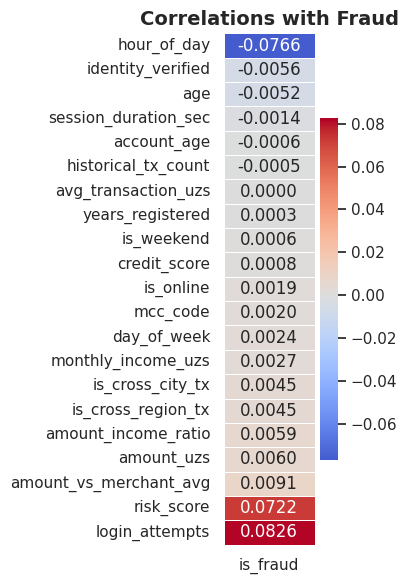

In [12]:
corr_fraud = (
    df.select_dtypes(include="number").corr()["is_fraud"].drop("is_fraud").sort_values()
)

fig, ax = plt.subplots(figsize=(4, 6))
sns.heatmap(
    corr_fraud.to_frame(),
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
plt.title("Correlations with Fraud")
plt.tight_layout()
plt.show()

Now we will do further EDA on features with higher correlation:

<Axes: xlabel='hour_of_day', ylabel='Count'>

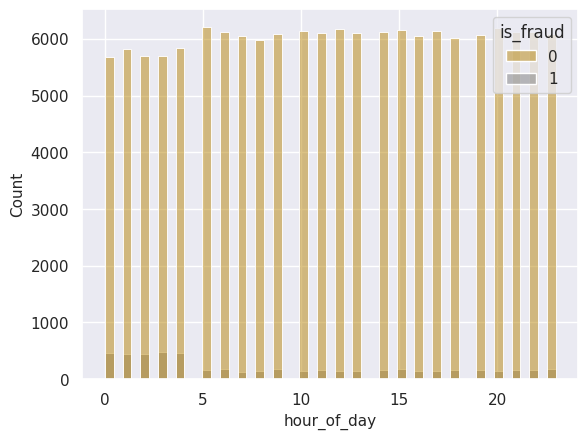

In [13]:
sns.histplot(data=df, x="hour_of_day", hue="is_fraud")